In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split,KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier,RandomForestClassifier,StackingClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb


In [2]:
data = pd.read_csv('out.csv')
data

,url,source,label,url_length,starts_with_ip,url_entropy,has_punycode,digit_letter_ratio,dot_count,at_count,dash_count,tld_count,domain_has_digits,subdomain_count,nan_char_entropy,has_internal_links,whois_data,domain_age_days
0,apaceast.cloudguest.central.arubanetworks.com,Cisco-Umbrella,legitimate,45,False,3.924535,False,0.000000,4,0,0,0,False,3,0.310387,False,"{'domain_name': ['ARUBANETWORKS.COM', 'arubane...",8250.0
1,quintadonoval.com,Majestic,legitimate,17,False,3.572469,False,0.000000,1,0,0,0,False,0,0.240439,False,"{'domain_name': ['QUINTADONOVAL.COM', 'quintad...",10106.0
2,nomadfactory.com,Majestic,legitimate,16,False,3.327820,False,0.000000,1,0,0,0,False,0,0.250000,False,"{'domain_name': ['NOMADFACTORY.COM', 'nomadfac...",8111.0
3,tvarenasport.com,Majestic,legitimate,16,False,3.500000,False,0.000000,1,0,0,0,False,0,0.250000,False,"{'domain_name': ['TVARENASPORT.COM', 'tvarenas...",5542.0
4,widget.cluster.groovehq.com,Cisco-Umbrella,legitimate,27,False,3.930270,False,0.000000,3,0,0,0,False,2,0.352214,False,"{'domain_name': 'GROOVEHQ.COM', 'registrar': '...",5098.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499995,http://atualizacao.novoatendimentocaixa.ml/sinbc,Phishing.Database,phishing,48,False,4.068902,False,0.000000,2,0,0,0,False,1,0.557393,False,"{'domain_name': 'novoatend', 'registrar': None...",NaN
2499996,https://ingcomptebe-1cd7e.firebaseapp.com,Phishing.Database,phishing,41,False,4.257078,False,0.060606,2,0,1,0,False,1,0.555799,False,NaN,NaN
2499997,http://yonphweisdowedych.chaseonlinemarketing....,Phishing.Database,phishing,66,False,4.393366,False,0.000000,2,0,0,0,False,1,0.581139,False,NaN,NaN
2499998,http://alternateangle.in/~pugepupgee/.wkwk/lkd...,Phishing.Database,phishing,102,False,4.763413,False,0.194444,3,0,0,0,False,0,0.787769,False,"{'domain_name': 'alternateangle.in', 'registra...",4622.0


In [3]:
data.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 18 columns):
 #   Column              Dtype  
---  ------              -----  
 0   url                 str    
 1   source              str    
 2   label               str    
 3   url_length          int64  
 4   starts_with_ip      bool   
 5   url_entropy         float64
 6   has_punycode        bool   
 7   digit_letter_ratio  float64
 8   dot_count           int64  
 9   at_count            int64  
 10  dash_count          int64  
 11  tld_count           int64  
 12  domain_has_digits   bool   
 13  subdomain_count     int64  
 14  nan_char_entropy    float64
 15  has_internal_links  bool   
 16  whois_data          str    
 17  domain_age_days     float64
dtypes: bool(4), float64(4), int64(6), str(4)
memory usage: 2.4 GB


In [4]:
data.isna().sum()

url                        1
source                     0
label                      0
url_length                 0
starts_with_ip             0
url_entropy                0
has_punycode               0
digit_letter_ratio         1
dot_count                  0
at_count                   0
dash_count                 0
tld_count                  0
domain_has_digits          0
subdomain_count            0
nan_char_entropy           0
has_internal_links         0
whois_data            545300
domain_age_days       750689
dtype: int64

In [5]:
mapping = {'legitimate':0,'phishing':1}
data["label"] = data["label"].map(mapping)

In [6]:
X = data.drop('label' , axis=1)
y = data['label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
X_train.info()


<class 'pandas.DataFrame'>
Index: 2000000 entries, 2454668 to 2006649
Data columns (total 17 columns):
 #   Column              Dtype  
---  ------              -----  
 0   url                 str    
 1   source              str    
 2   url_length          int64  
 3   starts_with_ip      bool   
 4   url_entropy         float64
 5   has_punycode        bool   
 6   digit_letter_ratio  float64
 7   dot_count           int64  
 8   at_count            int64  
 9   dash_count          int64  
 10  tld_count           int64  
 11  domain_has_digits   bool   
 12  subdomain_count     int64  
 13  nan_char_entropy    float64
 14  has_internal_links  bool   
 15  whois_data          str    
 16  domain_age_days     float64
dtypes: bool(4), float64(4), int64(6), str(3)
memory usage: 221.3 MB


In [9]:
data['url'].isna().sum()

np.int64(1)

In [10]:
data_info = {}

In [11]:
X_train['url_length'] = X_train['url'].str.len()

In [12]:
X_train['is_https'] = X_train['url'].apply(lambda x: 1 if str(x).startswith('https') else 0).astype('int8')


In [13]:
X_train.drop('url',axis=1,inplace=True)

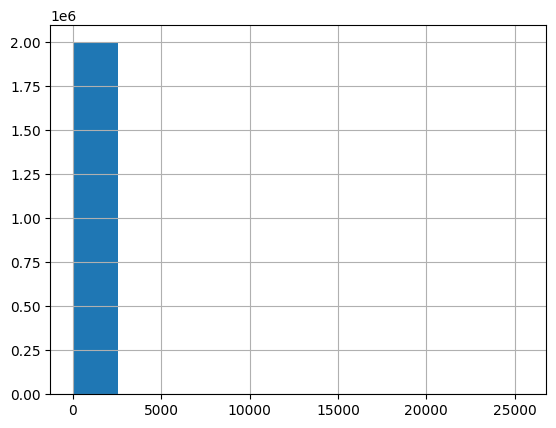

In [14]:
X_train['url_length'].hist()
data_info['url_length_median'] = X_train['url_length'].median()
X_train['url_length'] = X_train['url_length'].fillna(data_info['url_length_median']).astype('float32')

In [15]:
X_train['source'].value_counts()

source
Phishing.Database      934984
Majestic               522528
Cisco-Umbrella         477621
PhishTank               64480
OpenPhish-Community       387
Name: count, dtype: int64

In [16]:
le = LabelEncoder()
le.fit(X_train['source'])
X_train['source'] = le.transform(X_train['source']).astype('int8')

In [17]:
X_train['starts_with_ip'] = X_train['starts_with_ip'].astype("int8")

In [18]:
X_train['url_entropy'] = X_train['url_entropy'].astype('float32')

In [19]:
X_train['has_punycode'] = X_train['has_punycode'].astype('int8')

In [20]:
data_info['digit_letter_ratio_median'] = X_train['digit_letter_ratio'].median()
X_train['digit_letter_ratio'] = X_train['digit_letter_ratio'].fillna(data_info['digit_letter_ratio_median'])
X_train['digit_letter_ratio'] = X_train['digit_letter_ratio'].astype('float32')


In [21]:
X_train['dot_count'] = X_train['dot_count'].astype('int16')

In [22]:
X_train['at_count'].value_counts()
X_train['at_count'] = X_train['at_count'].astype('int8')

In [23]:
X_train['dash_count'].value_counts(dropna=False)
X_train['dash_count'] = X_train['dash_count'].astype('int16')


In [24]:
X_train['tld_count'].value_counts(dropna=False)
X_train['tld_count'] = X_train['tld_count'].astype('int8')


In [25]:
X_train['domain_has_digits'] = X_train['domain_has_digits'].astype("int8")

In [26]:
X_train['subdomain_count'] =  X_train['subdomain_count'].astype("int8")

In [27]:
X_train['nan_char_entropy'] = X_train['nan_char_entropy'].astype('float32')

In [28]:
X_train['has_internal_links'] = X_train['has_internal_links'].astype("int8")

In [29]:
X_train['whois_data'].value_counts(dropna=False)

whois_data
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [30]:
X_train.drop('whois_data',axis=1,inplace=True)

In [31]:
X_train['domain_age_days'].value_counts(dropna=False)

domain_age_days
NaN        600810
4167.0      25668
353.0       20854
3042.0      18997
7122.0      15519
            ...  
11632.0         1
12266.0         1
16323.0         1
11644.0         1
12961.0         1
Name: count, Length: 12058, dtype: int64

In [32]:
def preprocing(df,data_info,le_encoder):

    df = df.copy()
    df['url_length'] = df['url'].str.len()
    df['is_https'] = df['url'].apply(lambda x: 1 if str(x).startswith('https') else 0).astype('int8')

    df.drop('url',axis=1,inplace=True)
    df['url_length'] = df['url_length'].fillna(data_info['url_length_median'])
    
            
    df['source'] = le_encoder.transform(df['source']).astype('int8')
    df['starts_with_ip'] = df['starts_with_ip'].astype('int8')
    df['url_entropy'] = df['url_entropy'].astype('float32')
    df['has_punycode'] = df['has_punycode'].astype('int8')
    df['digit_letter_ratio'] = df['digit_letter_ratio'].fillna(data_info['digit_letter_ratio_median'])
    df['digit_letter_ratio'] = df['digit_letter_ratio'].astype('float32')
    df['dot_count'] = df['dot_count'].astype('int16')
    df['at_count'] = df['at_count'].astype('int8')
    df['dash_count'] = df['dash_count'].astype('int16')
    df['tld_count'] = df['tld_count'].astype('int8')
    df['domain_has_digits'] = df['domain_has_digits'].astype("int8")
    df['subdomain_count'] = df['subdomain_count'].astype("int8")
    df['nan_char_entropy'] = df['nan_char_entropy'].astype('float32')
    df['has_internal_links'] = df['has_internal_links'].astype("int8")
    df.drop('whois_data',axis=1,inplace=True)
    df['domain_age_days'] = df['domain_age_days'].fillna(-1).astype('float32')
    return df

In [33]:
X_train['domain_age_days'] = X_train['domain_age_days'].fillna(-1).astype('float32')

In [56]:
X_train.drop('source',axis=1,inplace=True)

In [34]:
X_test = preprocing(X_test,data_info,le)

In [37]:
X_test.isna().sum()

source                0
url_length            0
starts_with_ip        0
url_entropy           0
has_punycode          0
digit_letter_ratio    0
dot_count             0
at_count              0
dash_count            0
tld_count             0
domain_has_digits     0
subdomain_count       0
nan_char_entropy      0
has_internal_links    0
domain_age_days       0
is_https              0
dtype: int64

In [57]:
model1 = xgb.XGBClassifier()

In [58]:
model1.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [59]:
y_pred = model1.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train,model1.predict(X_train))

# print(classification_report(y_test, y_pred))
acc_test,acc_train

(0.999994, 0.9999995)

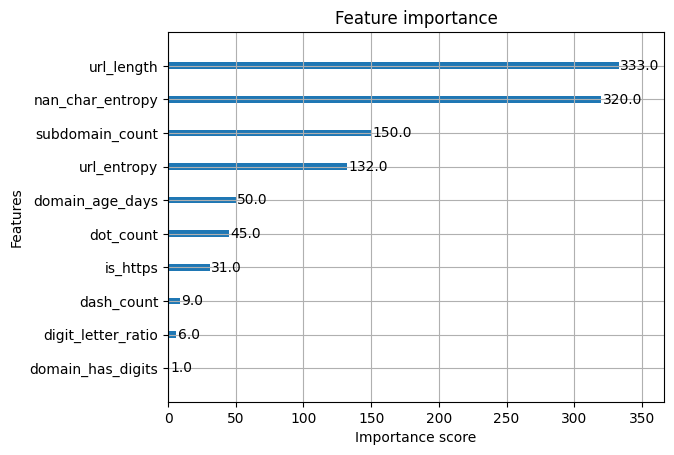

In [60]:
xgb.plot_importance(model1)
plt.show()

In [53]:
X_test.drop('source',axis=1,inplace=True)

In [61]:

model2 = LogisticRegression()
model2.fit(X_train,y_train)

C:\Users\erikg\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
y_pred = model2.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train,model2.predict(X_train))

# print(classification_report(y_test, y_pred))
acc_test,acc_train

(0.994196, 0.9941095)

In [65]:
model3 = DecisionTreeClassifier(max_depth=10)
model3.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [66]:
y_pred = model3.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train,model3.predict(X_train))

# print(classification_report(y_test, y_pred))
acc_test,acc_train

(0.999988, 0.999995)

In [67]:
import lightgbm as lgb

In [72]:
model4 = lgb.LGBMClassifier()
model4.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 999851, number of negative: 1000149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1401
[LightGBM] [Info] Number of data points in the train set: 2000000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499926 -> initscore=-0.000298
[LightGBM] [Info] Start training from score -0.000298


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [74]:
y_pred = model4.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train,model4.predict(X_train))
print(classification_report(y_test, y_pred))
acc_test,acc_train

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    249851
           1       1.00      1.00      1.00    250149

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



(0.999992, 1.0)